In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
from matplotlib.patches import Rectangle

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

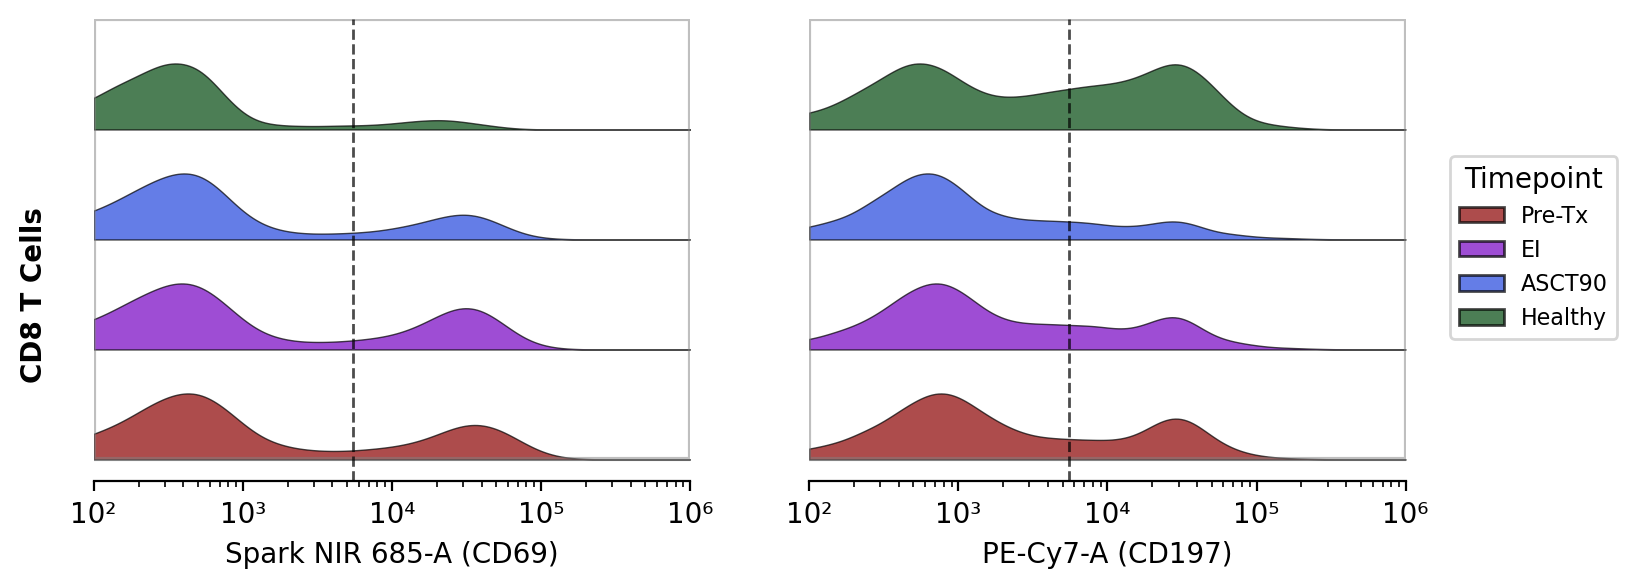

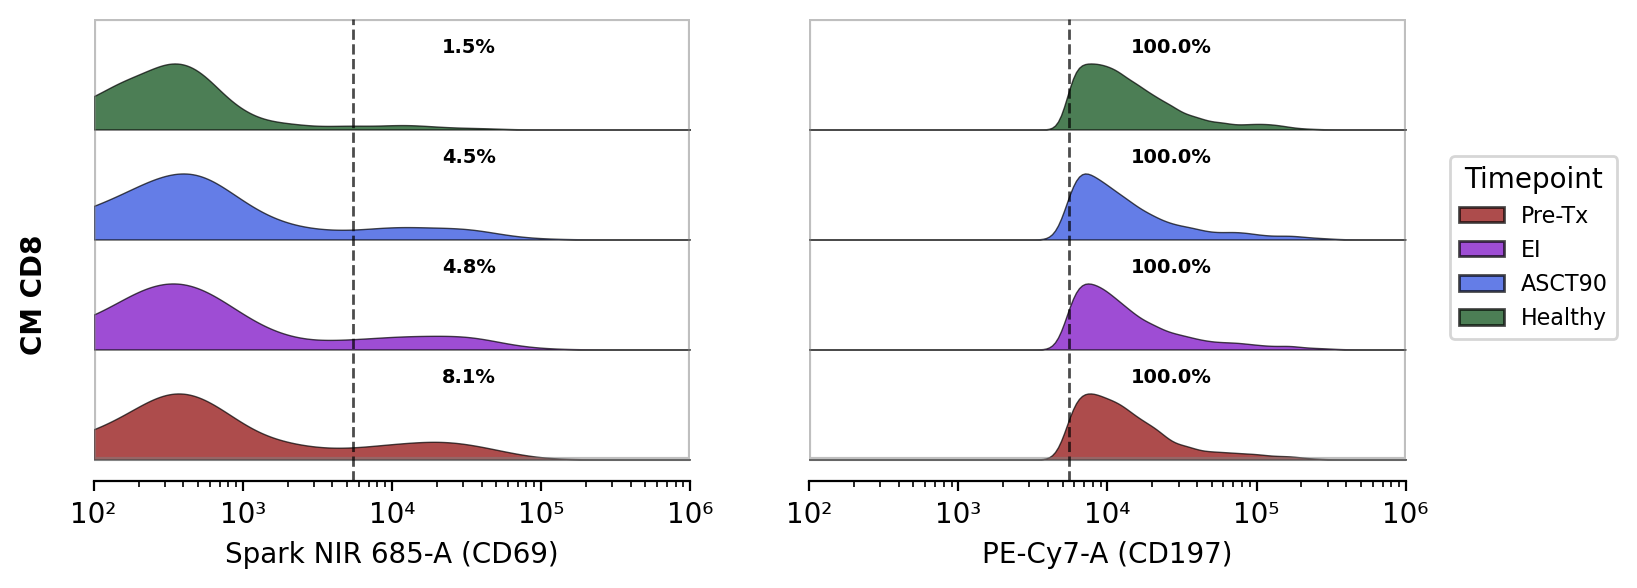

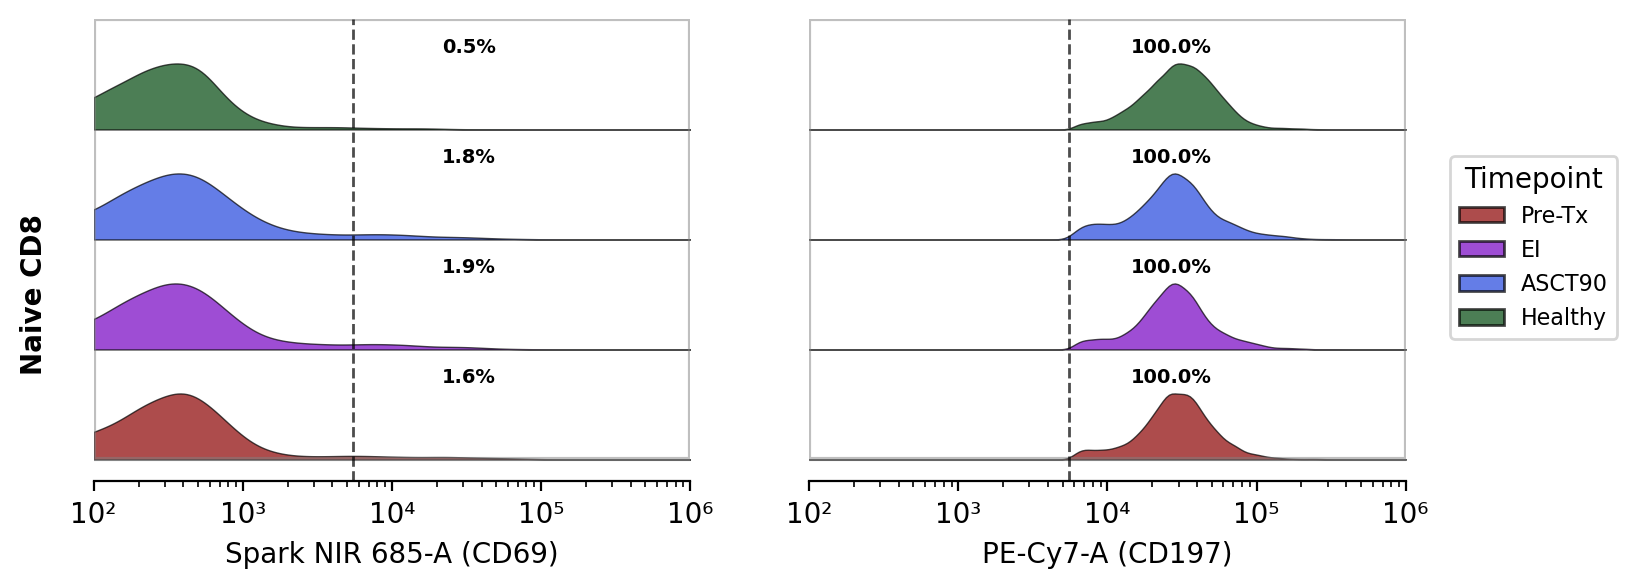

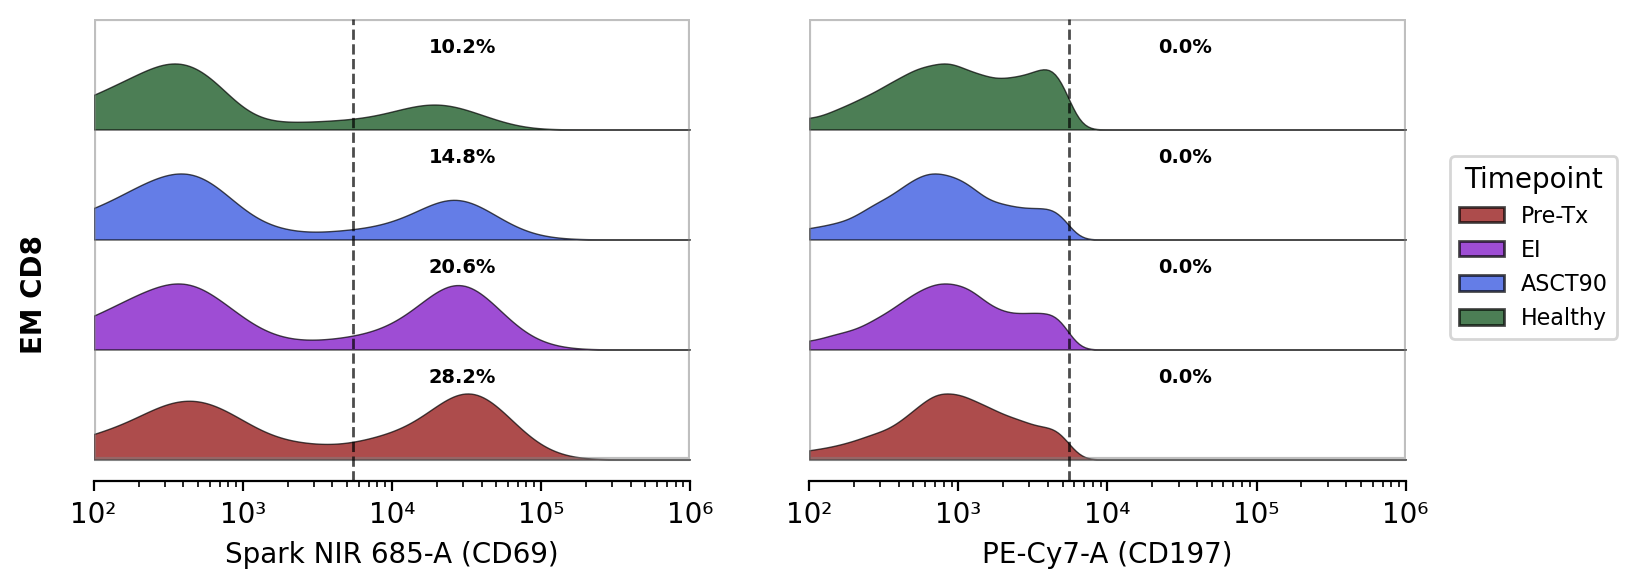

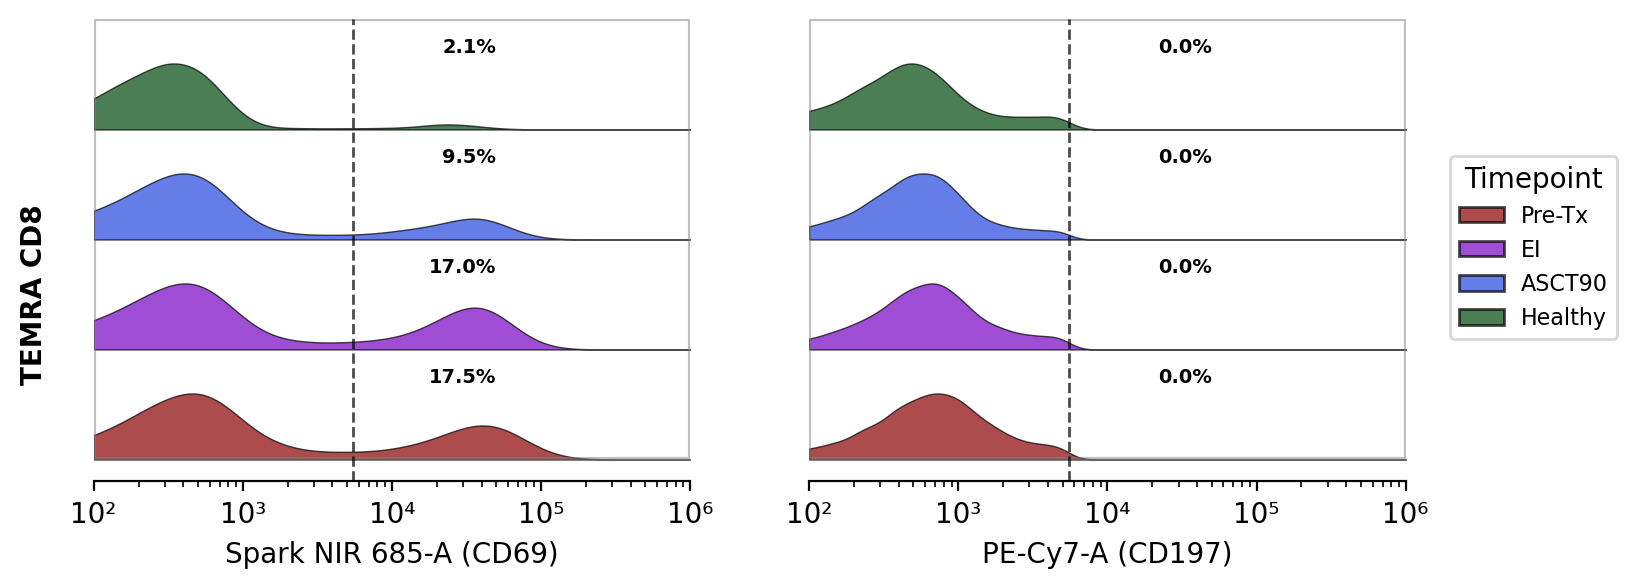

In [2]:
# 1. Load percent lookup from the statistics CSV
# Read the CSV; it has one row per (condition × population × marker_type)
bmmc_mfi_stats_path = "../../data/figure-inputs/flow/bm_mfi_stats.csv"
stats_df = pd.read_csv(bmmc_mfi_stats_path)

# Extract the condition string from the filename column.
# e.g. "Healthy - Ungated.fcs" → "Healthy"
stats_df['condition'] = stats_df['filename'].str.split(' - ').str[0]

# Determine which marker type (CD69 or CD197) each population row belongs to.
# The 'population' column starts with "CD69+" or "CD197+"
# We extract just the marker name so we can match it to the plot markers.
stats_df['marker_prefix'] = stats_df['population'].str.extract(r'^(CD\d+)\+')
# Now 'marker_prefix' column contains "CD69" or "CD197"

# Build a fast lookup dict:
#   key  → (condition, parentPopulation, marker_prefix)
#   value → percent (float)
# Using .set_index(...) and .to_dict() gives O(1) lookups later.
percent_lookup = (
    stats_df
    .set_index(['condition', 'parentPopulation', 'marker_prefix'])['percent']
    .to_dict()
)

# 2. Map each full marker channel name to its short CD prefix
# Your marker strings contain the CD name inside parentheses, e.g. "(CD69)"
# We build a dict so that inside the loop we can look up the right prefix.
marker_to_prefix = {}
for marker in ['FJComp-Spark NIR 685-A (CD69)', 'FJComp-PE-Cy7-A (CD197)']:
    short = marker.split('(')[-1].replace(')', '')
    marker_to_prefix[marker] = short

bmmc_mfdi_path = "../../data/figure-inputs/flow/bmmc_mfi_data/"
paths = [p for p in os.listdir(bmmc_mfdi_path) if p.endswith('.tsv')]

conditions_to_plot = ['Pre-Tx', 'EI', 'ASCT90', 'Healthy']

timepoint_cmap = {
    'Pre-Tx': "#8B0000",
    'EI': "#7502C2",
    'ASCT90': '#2346DE',
    'Healthy': '#00470D'
}

populations_to_plot = [
    "CD8 T Cells",
    "CM CD8",
    "Naive CD8",
    "EM CD8",
    "TEMRA CD8"
]

markers_to_plot = [
    'FJComp-Spark NIR 685-A (CD69)',
    'FJComp-PE-Cy7-A (CD197)'
]

data_dict = {}
for path in paths:
    parts = path.split(" - ")
    condition = parts[0]
    population = parts[2].replace(".tsv", "")
    df = pd.read_table(os.path.join(bmmc_mfdi_path, path))
    data_dict[(condition, population)] = df

figures_dict = {}

for population in populations_to_plot:
    n_markers = len(markers_to_plot)
    fig, axes = plt.subplots(1, n_markers, figsize=(4*n_markers, 3))
    if n_markers == 1:
        axes = [axes]

    for idx, marker in enumerate(markers_to_plot):
        ax = axes[idx]
        y_offset = 0
        pop_start_y = 0
        cd_prefix = marker_to_prefix[marker]

        for condition in conditions_to_plot:
            if (condition, population) not in data_dict:
                y_offset += 1
                continue

            df = data_dict[(condition, population)]
            if marker not in df.columns:
                y_offset += 1
                continue

            data = df[marker].dropna()
            data = data[data > 0]

            if len(data) < 10:
                y_offset += 1
                continue

            log_data = np.log10(data)
            kde = stats.gaussian_kde(log_data)

            x_log_range = np.linspace(2, 6, 200)
            density = kde(x_log_range)
            density = density / density.max() * 0.6
            x_linear = 10 ** x_log_range

            condition_color = timepoint_cmap[condition]
            ax.fill_between(x_linear, y_offset, y_offset + density,
                            alpha=0.7, color=condition_color,
                            edgecolor='black', linewidth=0.5)
            lookup_key = (condition, population, cd_prefix)

            pct_value = percent_lookup.get(lookup_key)

            if pct_value is not None:
                ax.annotate(
                    f"{pct_value:.1f}%",
                    xy=(10**4.7, y_offset + 0.75),
                    xycoords='data',          
                    fontsize=7,
                    va='center',
                    ha='right',
                    color='black',
                    fontweight='bold'
                )

            y_offset += 1

        pop_end_y = y_offset
        ax.axvline(x=5500, color='black', linestyle='--', alpha=0.7, linewidth=1, zorder=10)

        ax.set_xscale('log')
        ax.set_xlim(10**2, 10**6)
        ax.set_xticks([10**2, 10**3, 10**4, 10**5, 10**6])
        ax.set_xticklabels(['10²', '10³', '10⁴', '10⁵', '10⁶'])
        ax.set_xlabel(marker.replace("FJComp-", ""), fontsize=10)
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_ylim(-0.2, y_offset)
        ax.grid(False)

        rect = Rectangle((10**2, pop_start_y), 10**6 - 10**2,
                          pop_end_y - pop_start_y,
                          linewidth=1.5, edgecolor='gray', facecolor='none',
                          alpha=0.5)
        ax.add_patch(rect)

        if idx == 0:
            center_y = len(conditions_to_plot) / 2 - 0.5
            ax.text(-0.1, center_y, population,
                    transform=ax.get_yaxis_transform(),
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    rotation=90)

    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=timepoint_cmap[cond],
                                     edgecolor='black', alpha=0.7)
                       for cond in conditions_to_plot]
    fig.legend(legend_elements, conditions_to_plot, loc='center',
               bbox_to_anchor=(0.98, 0.5), fontsize=8, title='Timepoint')

    plt.subplots_adjust(left=0.08)
    figures_dict[population] = fig

plt.show()

In [3]:
for population, fig in figures_dict.items():
    fig.savefig(f"../../data/figure-outputs/supplementary-5/sup_5c_{population.replace(' ', '_')}.pdf", bbox_inches='tight', dpi=200)